In [904]:
import os

print(os.getcwd())

c:\Users\pc\OneDrive\Desktop\deeplearnig


In [905]:
import pandas as pd

df = pd.read_csv("bank+marketing/bank/bank-full.csv", sep=";")

df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


In [906]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 45211
Columns: 17


In [907]:
print(df.columns)

Index(['age', 'job', 'marital', 'education', 'default', 'balance', 'housing',
       'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'y'],
      dtype='str')


In [908]:
print(df.dtypes)

age          int64
job            str
marital        str
education      str
default        str
balance      int64
housing        str
loan           str
contact        str
day          int64
month          str
duration     int64
campaign     int64
pdays        int64
previous     int64
poutcome       str
y              str
dtype: object


In [909]:
print(df.isna().sum())

age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
y            0
dtype: int64


In [910]:
unknown_counts = (df == "unknown").sum()

print(unknown_counts)

age              0
job            288
marital          0
education     1857
default          0
balance          0
housing          0
loan             0
contact      13020
day              0
month            0
duration         0
campaign         0
pdays            0
previous         0
poutcome     36959
y                0
dtype: int64


In [911]:
print(df["y"].value_counts())

y
no     39922
yes     5289
Name: count, dtype: int64


In [912]:
print(df.describe())

                age        balance           day      duration      campaign  \
count  45211.000000   45211.000000  45211.000000  45211.000000  45211.000000   
mean      40.936210    1362.272058     15.806419    258.163080      2.763841   
std       10.618762    3044.765829      8.322476    257.527812      3.098021   
min       18.000000   -8019.000000      1.000000      0.000000      1.000000   
25%       33.000000      72.000000      8.000000    103.000000      1.000000   
50%       39.000000     448.000000     16.000000    180.000000      2.000000   
75%       48.000000    1428.000000     21.000000    319.000000      3.000000   
max       95.000000  102127.000000     31.000000   4918.000000     63.000000   

              pdays      previous  
count  45211.000000  45211.000000  
mean      40.197828      0.580323  
std      100.128746      2.303441  
min       -1.000000      0.000000  
25%       -1.000000      0.000000  
50%       -1.000000      0.000000  
75%       -1.000000      0.

In [913]:
categorical_cols = df.select_dtypes(include="str").columns

for col in categorical_cols:
    print(f"{col}: {df[col].nunique()} unique values")

job: 12 unique values
marital: 3 unique values
education: 4 unique values
default: 2 unique values
housing: 2 unique values
loan: 2 unique values
contact: 3 unique values
month: 12 unique values
poutcome: 4 unique values
y: 2 unique values


In [914]:
X = df.drop("y", axis=1)
y = df["y"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (45211, 16)
y shape: (45211,)


In [915]:
y = y.map({"no": 0, "yes": 1})

print(y.head())
print(y.value_counts())

0    0
1    0
2    0
3    0
4    0
Name: y, dtype: int64
y
0    39922
1     5289
Name: count, dtype: int64


In [916]:
numerical_cols = X.select_dtypes(include="number").columns
categorical_cols = X.select_dtypes(include="str").columns

print("Numerical features:")
print(numerical_cols)

print("\nCategorical features:")
print(categorical_cols)

Numerical features:
Index(['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous'], dtype='str')

Categorical features:
Index(['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact',
       'month', 'poutcome'],
      dtype='str')


In [917]:
from sklearn.model_selection import train_test_split

X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

print("Training:", X_train.shape)
print("Temporary:", X_temp.shape)

Training: (31647, 16)
Temporary: (13564, 16)


In [918]:
X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

print("Training:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)

Training: (31647, 16)
Validation: (6782, 16)
Test: (6782, 16)


In [919]:
print("Training target distribution:")
print(y_train.value_counts(normalize=True))

print("\nValidation target distribution:")
print(y_val.value_counts(normalize=True))

print("\nTest target distribution:")
print(y_test.value_counts(normalize=True))

Training target distribution:
y
0    0.883022
1    0.116978
Name: proportion, dtype: float64

Validation target distribution:
y
0    0.882925
1    0.117075
Name: proportion, dtype: float64

Test target distribution:
y
0    0.883073
1    0.116927
Name: proportion, dtype: float64


In [920]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categorical_cols)
    ]
)

print("Preprocessing pipeline created successfully.")

Preprocessing pipeline created successfully.


In [921]:
X_train_processed = preprocessor.fit_transform(X_train)

X_val_processed = preprocessor.transform(X_val)

X_test_processed = preprocessor.transform(X_test)

print("Training shape:", X_train_processed.shape)
print("Validation shape:", X_val_processed.shape)
print("Test shape:", X_test_processed.shape)

Training shape: (31647, 51)
Validation shape: (6782, 51)
Test shape: (6782, 51)


In [922]:
print("First 5 rows:")
print(X_train_processed[:5])

print("\nShape of one customer:")
print(X_train_processed[0].shape)

First 5 rows:
[[-0.93046095 -0.44381323 -0.8170392  -0.6801517  -0.5668498  -0.4100377
  -0.23477381  0.          0.          0.          0.          0.
   0.          0.          1.          0.          0.          0.
   0.          0.          1.          0.          0.          1.
   0.          0.          1.          0.          0.          1.
   1.          0.          1.          0.          0.          0.
   0.          0.          0.          0.          1.          0.
   0.          0.          0.          0.          0.          0.
   0.          0.          1.        ]
 [-0.55387131 -0.3806249   0.14323561 -0.21454513 -0.5668498  -0.4100377
  -0.23477381  0.          0.          0.          0.          0.
   0.          0.          1.          0.          0.          0.
   0.          0.          1.          0.          0.          1.
   0.          0.          1.          0.          0.          1.
   1.          0.          1.          0.          0.          1.
   0.    

In [923]:
import torch

X_train_tensor = torch.tensor(X_train_processed, dtype=torch.float32)
X_val_tensor = torch.tensor(X_val_processed, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test_processed, dtype=torch.float32)

print("Training tensor shape:", X_train_tensor.shape)
print("Validation tensor shape:", X_val_tensor.shape)
print("Test tensor shape:", X_test_tensor.shape)

Training tensor shape: torch.Size([31647, 51])
Validation tensor shape: torch.Size([6782, 51])
Test tensor shape: torch.Size([6782, 51])


In [924]:
y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val.values, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.float32)

print("Training target shape:", y_train_tensor.shape)
print("Validation target shape:", y_val_tensor.shape)
print("Test target shape:", y_test_tensor.shape)

Training target shape: torch.Size([31647])
Validation target shape: torch.Size([6782])
Test target shape: torch.Size([6782])


In [925]:
from torch.utils.data import TensorDataset, DataLoader

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

print("Training batches:", len(train_loader))
print("Validation batches:", len(val_loader))
print("Test batches:", len(test_loader))

Training batches: 495
Validation batches: 106
Test batches: 106


In [926]:
X_batch, y_batch = next(iter(train_loader))

print("Feature batch shape:", X_batch.shape)
print("Target batch shape:", y_batch.shape)

print("\nFirst customer's features:")
print(X_batch[0])

print("\nFirst customer's target:")
print(y_batch[0])

Feature batch shape: torch.Size([64, 51])
Target batch shape: torch.Size([64])

First customer's features:
tensor([-0.5539,  3.9400, -0.0968,  3.1140,  0.0773, -0.4100, -0.2348,  0.0000,
         0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
         1.0000,  0.0000,  0.0000,  0.0000,  0.0000,  1.0000,  0.0000,  0.0000,
         1.0000,  0.0000,  1.0000,  0.0000,  0.0000,  1.0000,  1.0000,  0.0000,
         1.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
         0.0000,  0.0000,  0.0000,  1.0000,  0.0000,  0.0000,  0.0000,  0.0000,
         0.0000,  0.0000,  1.0000])

First customer's target:
tensor(1.)


In [927]:
import torch.nn as nn

class BankMarketingNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.network = nn.Sequential(
            nn.Linear(51, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 1)
        )

    def forward(self, x):
        return self.network(x)


model = BankMarketingNN()

print(model)

BankMarketingNN(
  (network): Sequential(
    (0): Linear(in_features=51, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=32, bias=True)
    (3): ReLU()
    (4): Linear(in_features=32, out_features=1, bias=True)
  )
)


In [928]:
total_params = sum(
    parameter.numel()
    for parameter in model.parameters()
    if parameter.requires_grad
)

print("Trainable parameters:", total_params)

Trainable parameters: 5441


In [929]:
model.eval()

with torch.no_grad():
    outputs = model(X_batch)

print("Output shape:", outputs.shape)
print("\nFirst 10 outputs:")
print(outputs[:10])

Output shape: torch.Size([64, 1])

First 10 outputs:
tensor([[ 0.1436],
        [-0.0259],
        [-0.0089],
        [ 0.0578],
        [ 0.0096],
        [ 0.0487],
        [-0.0223],
        [ 0.0202],
        [ 0.0888],
        [ 0.0784]])


In [930]:
print("Training class counts:")
print(y_train.value_counts())

negative_count = (y_train == 0).sum()
positive_count = (y_train == 1).sum()

print("\nNegative samples:", negative_count)
print("Positive samples:", positive_count)

Training class counts:
y
0    27945
1     3702
Name: count, dtype: int64

Negative samples: 27945
Positive samples: 3702


In [931]:
pos_weight = negative_count / positive_count

print("Positive class weight:", pos_weight)

Positive class weight: 7.548622366288493


In [932]:
pos_weight_tensor = torch.tensor([pos_weight], dtype=torch.float32)

criterion = nn.BCEWithLogitsLoss(
    pos_weight=pos_weight_tensor
)

print("Loss function:")
print(criterion)

Loss function:
BCEWithLogitsLoss()


In [933]:
model.train()

X_batch, y_batch = next(iter(train_loader))

outputs = model(X_batch)

loss = criterion(
    outputs.squeeze(1),
    y_batch
)

print("Output shape:", outputs.shape)
print("Loss:", loss.item())

Output shape: torch.Size([64, 1])
Loss: 1.4535926580429077


In [934]:
# Clear any old gradients
model.zero_grad()

# Forward pass
outputs = model(X_batch)

# Calculate loss
loss = criterion(
    outputs.squeeze(1),
    y_batch
)

# Backpropagation
loss.backward()

print("Loss:", loss.item())

print("\nGradient shape of first layer:")
print(model.network[0].weight.grad.shape)

print("\nFirst 10 gradients:")
print(model.network[0].weight.grad.flatten()[:10])

Loss: 1.4535926580429077

Gradient shape of first layer:
torch.Size([64, 51])

First 10 gradients:
tensor([ 4.3297e-04, -1.9032e-03,  3.7311e-04, -2.0511e-04,  4.8223e-05,
         5.3160e-04,  1.4915e-04,  0.0000e+00,  0.0000e+00,  0.0000e+00])


In [935]:
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

print(optimizer)

Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0
)


In [936]:
# Save one weight before the update
weight_before = model.network[0].weight[0, 0].item()

# Update the model's parameters
optimizer.step()

# Check the same weight after the update
weight_after = model.network[0].weight[0, 0].item()

print("Weight before update:", weight_before)
print("Weight after update:", weight_after)
print("Change:", weight_after - weight_before)

Weight before update: -0.01586490124464035
Weight after update: -0.016864877194166183
Change: -0.0009999759495258331


In [937]:
# Forward pass after the weight update
outputs_after = model(X_batch)

# Calculate the new loss
loss_after = criterion(
    outputs_after.squeeze(1),
    y_batch
)

print("Loss before update: 1.4809300899505615")
print("Loss after update:", loss_after.item())

Loss before update: 1.4809300899505615
Loss after update: 1.4394350051879883


In [938]:
model.train()

total_loss = 0

for X_batch, y_batch in train_loader:

    # 1. Clear old gradients
    optimizer.zero_grad()

    # 2. Forward pass
    outputs = model(X_batch)

    # 3. Calculate loss
    loss = criterion(
        outputs.squeeze(1),
        y_batch
    )

    # 4. Backpropagation
    loss.backward()

    # 5. Update weights
    optimizer.step()

    # Add this batch's loss
    total_loss += loss.item()

average_loss = total_loss / len(train_loader)

print("Average training loss:", average_loss)

Average training loss: 0.729928426700409


In [939]:
model.eval()

val_total_loss = 0

with torch.no_grad():

    for X_batch, y_batch in val_loader:

        outputs = model(X_batch)

        loss = criterion(
            outputs.squeeze(1),
            y_batch
        )

        val_total_loss += loss.item()

average_val_loss = val_total_loss / len(val_loader)

print("Validation loss:", average_val_loss)

Validation loss: 0.641907700390186


In [940]:
num_epochs = 10

for epoch in range(num_epochs):

    # -------------------------
    # Training
    # -------------------------
    model.train()

    train_total_loss = 0

    for X_batch, y_batch in train_loader:

        optimizer.zero_grad()

        outputs = model(X_batch)

        loss = criterion(
            outputs.squeeze(1),
            y_batch
        )

        loss.backward()

        optimizer.step()

        train_total_loss += loss.item()

    train_loss = train_total_loss / len(train_loader)

    # -------------------------
    # Validation
    # -------------------------
    model.eval()

    val_total_loss = 0

    with torch.no_grad():

        for X_batch, y_batch in val_loader:

            outputs = model(X_batch)

            loss = criterion(
                outputs.squeeze(1),
                y_batch
            )

            val_total_loss += loss.item()

    val_loss = val_total_loss / len(val_loader)

    print(
        f"Epoch {epoch + 1}/{num_epochs} "
        f"| Train Loss: {train_loss:.4f} "
        f"| Val Loss: {val_loss:.4f}"
    )

Epoch 1/10 | Train Loss: 0.6299 | Val Loss: 0.6259
Epoch 2/10 | Train Loss: 0.6031 | Val Loss: 0.6171
Epoch 3/10 | Train Loss: 0.5830 | Val Loss: 0.5950
Epoch 4/10 | Train Loss: 0.5665 | Val Loss: 0.5852
Epoch 5/10 | Train Loss: 0.5528 | Val Loss: 0.5843
Epoch 6/10 | Train Loss: 0.5433 | Val Loss: 0.5878
Epoch 7/10 | Train Loss: 0.5333 | Val Loss: 0.5819
Epoch 8/10 | Train Loss: 0.5274 | Val Loss: 0.5843
Epoch 9/10 | Train Loss: 0.5207 | Val Loss: 0.5818
Epoch 10/10 | Train Loss: 0.5125 | Val Loss: 0.5856


In [941]:
import torch

example_logits = torch.tensor([-2.0, -1.0, 0.0, 1.0, 2.0])

probabilities = torch.sigmoid(example_logits)

print("Logits:")
print(example_logits)

print("\nProbabilities:")
print(probabilities)

Logits:
tensor([-2., -1.,  0.,  1.,  2.])

Probabilities:
tensor([0.1192, 0.2689, 0.5000, 0.7311, 0.8808])


In [942]:
model.eval()

all_probabilities = []
all_predictions = []
all_targets = []

with torch.no_grad():

    for X_batch, y_batch in val_loader:

        # Get raw logits
        outputs = model(X_batch)

        # Convert logits to probabilities
        probabilities = torch.sigmoid(outputs.squeeze(1))

        # Convert probabilities into 0/1 predictions
        predictions = (probabilities >= 0.5).float()

        # Store results
        all_probabilities.extend(probabilities.numpy())
        all_predictions.extend(predictions.numpy())
        all_targets.extend(y_batch.numpy())

print("First 10 probabilities:")
print(all_probabilities[:10])

print("\nFirst 10 predictions:")
print(all_predictions[:10])

print("\nFirst 10 actual targets:")
print(all_targets[:10])

First 10 probabilities:
[np.float32(0.007878581), np.float32(0.022539662), np.float32(0.37093976), np.float32(0.042461257), np.float32(0.002152536), np.float32(0.0033219808), np.float32(0.30501366), np.float32(0.0053302934), np.float32(0.21340433), np.float32(0.47905996)]

First 10 predictions:
[np.float32(0.0), np.float32(0.0), np.float32(0.0), np.float32(0.0), np.float32(0.0), np.float32(0.0), np.float32(0.0), np.float32(0.0), np.float32(0.0), np.float32(0.0)]

First 10 actual targets:
[np.float32(0.0), np.float32(0.0), np.float32(0.0), np.float32(0.0), np.float32(0.0), np.float32(0.0), np.float32(0.0), np.float32(0.0), np.float32(0.0), np.float32(0.0)]


In [943]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(
    all_targets,
    all_predictions
)

print("Validation Accuracy:", accuracy)

Validation Accuracy: 0.8432615747567089


In [944]:
from sklearn.metrics import precision_score, recall_score, f1_score

precision = precision_score(
    all_targets,
    all_predictions
)

recall = recall_score(
    all_targets,
    all_predictions
)

f1 = f1_score(
    all_targets,
    all_predictions
)

print("Validation Precision:", precision)
print("Validation Recall:", recall)
print("Validation F1-score:", f1)

Validation Precision: 0.41960549910340705
Validation Recall: 0.8841309823677582
Validation F1-score: 0.5691122821240373


In [946]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    all_targets,
    all_predictions
)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[5017  971]
 [  92  702]]


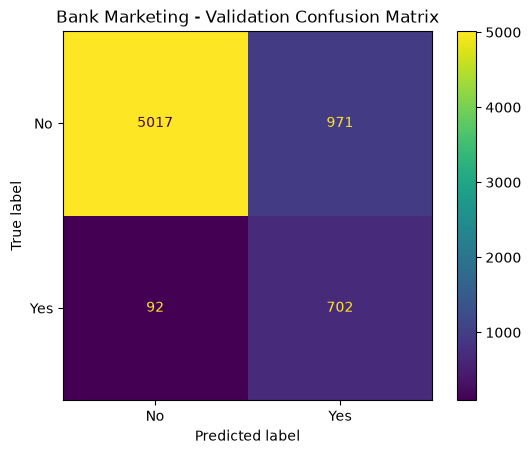

In [948]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No", "Yes"]
)

disp.plot()

plt.title("Bank Marketing - Validation Confusion Matrix")
plt.show()

In [950]:
from sklearn.metrics import roc_auc_score

roc_auc = roc_auc_score(
    all_targets,
    all_probabilities
)

print("Validation ROC-AUC:", roc_auc)

Validation ROC-AUC: 0.9295972297239316


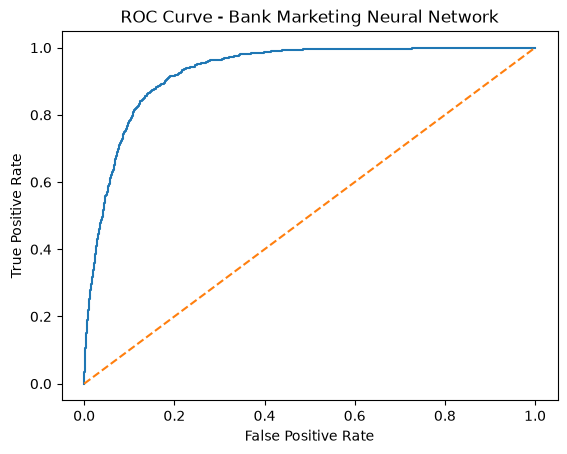

In [952]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

fpr, tpr, thresholds = roc_curve(
    all_targets,
    all_probabilities
)

plt.plot(fpr, tpr)
plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Bank Marketing Neural Network")

plt.show()

In [954]:
import numpy as np
from sklearn.metrics import precision_score, recall_score, f1_score

# Change the decision threshold
threshold = 0.7

# Convert probabilities into predictions
predictions_07 = (
    np.array(all_probabilities) >= threshold
).astype(int)

# Calculate metrics
precision_07 = precision_score(
    all_targets,
    predictions_07
)

recall_07 = recall_score(
    all_targets,
    predictions_07
)

f1_07 = f1_score(
    all_targets,
    predictions_07
)

print("Threshold:", threshold)
print("Precision:", precision_07)
print("Recall:", recall_07)
print("F1-score:", f1_07)

Threshold: 0.7
Precision: 0.5
Recall: 0.792191435768262
F1-score: 0.6130604288499025


In [956]:
import numpy as np
from sklearn.metrics import precision_score, recall_score, f1_score

thresholds_to_test = np.arange(0.1, 1.0, 0.1)

for threshold in thresholds_to_test:

    predictions = (
        np.array(all_probabilities) >= threshold
    ).astype(int)

    precision = precision_score(
        all_targets,
        predictions,
        zero_division=0
    )

    recall = recall_score(
        all_targets,
        predictions,
        zero_division=0
    )

    f1 = f1_score(
        all_targets,
        predictions,
        zero_division=0
    )

    print(
        f"Threshold: {threshold:.1f} "
        f"| Precision: {precision:.3f} "
        f"| Recall: {recall:.3f} "
        f"| F1: {f1:.3f}"
    )

Threshold: 0.1 | Precision: 0.275 | Recall: 0.975 | F1: 0.430
Threshold: 0.2 | Precision: 0.325 | Recall: 0.955 | F1: 0.485
Threshold: 0.3 | Precision: 0.360 | Recall: 0.935 | F1: 0.520
Threshold: 0.4 | Precision: 0.390 | Recall: 0.912 | F1: 0.546
Threshold: 0.5 | Precision: 0.420 | Recall: 0.884 | F1: 0.569
Threshold: 0.6 | Precision: 0.459 | Recall: 0.850 | F1: 0.596
Threshold: 0.7 | Precision: 0.500 | Recall: 0.792 | F1: 0.613
Threshold: 0.8 | Precision: 0.558 | Recall: 0.671 | F1: 0.609
Threshold: 0.9 | Precision: 0.661 | Recall: 0.419 | F1: 0.513


In [958]:
import torch.nn as nn

class BankMarketingNN_Dropout(nn.Module):
    def __init__(self):
        super().__init__()

        self.network = nn.Sequential(
            nn.Linear(51, 64),
            nn.ReLU(),
            nn.Dropout(0.30),

            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(0.30),

            nn.Linear(32, 1)
        )

    def forward(self, x):
        return self.network(x)


dropout_model = BankMarketingNN_Dropout()

print(dropout_model)

BankMarketingNN_Dropout(
  (network): Sequential(
    (0): Linear(in_features=51, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=64, out_features=32, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.3, inplace=False)
    (6): Linear(in_features=32, out_features=1, bias=True)
  )
)


In [960]:
dropout_optimizer = torch.optim.Adam(
    dropout_model.parameters(),
    lr=0.001
)

dropout_criterion = nn.BCEWithLogitsLoss(
    pos_weight=pos_weight_tensor
)

print("Optimizer and loss function created.")

Optimizer and loss function created.


In [962]:
dropout_model.train()

train_total_loss = 0

for X_batch, y_batch in train_loader:

    # Clear old gradients
    dropout_optimizer.zero_grad()

    # Forward pass
    outputs = dropout_model(X_batch)

    # Calculate loss
    loss = dropout_criterion(
        outputs.squeeze(1),
        y_batch
    )

    # Backpropagation
    loss.backward()

    # Update weights
    dropout_optimizer.step()

    train_total_loss += loss.item()

train_loss = train_total_loss / len(train_loader)

print("Dropout model - Training loss:", train_loss)

Dropout model - Training loss: 0.6676405385287121


In [964]:
dropout_model.eval()

val_total_loss = 0

with torch.no_grad():

    for X_batch, y_batch in val_loader:

        outputs = dropout_model(X_batch)

        loss = dropout_criterion(
            outputs.squeeze(1),
            y_batch
        )

        val_total_loss += loss.item()

dropout_val_loss = val_total_loss / len(val_loader)

print("Dropout model - Validation loss:", dropout_val_loss)

Dropout model - Validation loss: 0.6370251409287723


In [966]:
num_epochs = 10

for epoch in range(num_epochs):

    # -------------------------
    # Training
    # -------------------------
    dropout_model.train()

    train_total_loss = 0

    for X_batch, y_batch in train_loader:

        dropout_optimizer.zero_grad()

        outputs = dropout_model(X_batch)

        loss = dropout_criterion(
            outputs.squeeze(1),
            y_batch
        )

        loss.backward()
        dropout_optimizer.step()

        train_total_loss += loss.item()

    train_loss = train_total_loss / len(train_loader)

    # -------------------------
    # Validation
    # -------------------------
    dropout_model.eval()

    val_total_loss = 0

    with torch.no_grad():

        for X_batch, y_batch in val_loader:

            outputs = dropout_model(X_batch)

            loss = dropout_criterion(
                outputs.squeeze(1),
                y_batch
            )

            val_total_loss += loss.item()

    val_loss = val_total_loss / len(val_loader)

    print(
        f"Epoch {epoch + 1}/{num_epochs} "
        f"| Train Loss: {train_loss:.4f} "
        f"| Val Loss: {val_loss:.4f}"
    )

Epoch 1/10 | Train Loss: 0.5542 | Val Loss: 0.5833
Epoch 2/10 | Train Loss: 0.5552 | Val Loss: 0.5723
Epoch 3/10 | Train Loss: 0.5492 | Val Loss: 0.5908
Epoch 4/10 | Train Loss: 0.5423 | Val Loss: 0.5906
Epoch 5/10 | Train Loss: 0.5463 | Val Loss: 0.5736
Epoch 6/10 | Train Loss: 0.5373 | Val Loss: 0.5735
Epoch 7/10 | Train Loss: 0.5349 | Val Loss: 0.5873
Epoch 8/10 | Train Loss: 0.5371 | Val Loss: 0.5690
Epoch 9/10 | Train Loss: 0.5284 | Val Loss: 0.5812
Epoch 10/10 | Train Loss: 0.5299 | Val Loss: 0.5925


In [968]:
best_val_loss = float("inf")

current_val_loss = 0.5780

if current_val_loss < best_val_loss:
    best_val_loss = current_val_loss
    print("Validation loss improved!")
    print("New best validation loss:", best_val_loss)

Validation loss improved!
New best validation loss: 0.578


In [970]:
best_val_loss = float("inf")
patience_counter = 0
patience = 3

validation_losses = [0.60, 0.57, 0.55, 0.56, 0.58, 0.59]

for val_loss in validation_losses:

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0

        print(
            f"Validation improved → {val_loss:.2f}"
        )

    else:
        patience_counter += 1

        print(
            f"No improvement → {val_loss:.2f} "
            f"| Patience: {patience_counter}/{patience}"
        )

    if patience_counter >= patience:
        print("Early stopping triggered!")
        break

Validation improved → 0.60
Validation improved → 0.57
Validation improved → 0.55
No improvement → 0.56 | Patience: 1/3
No improvement → 0.58 | Patience: 2/3
No improvement → 0.59 | Patience: 3/3
Early stopping triggered!


In [972]:
import copy

num_epochs = 30
patience = 3

best_val_loss = float("inf")
patience_counter = 0

best_model_state = None

for epoch in range(num_epochs):

    # -------------------------
    # Training
    # -------------------------
    dropout_model.train()

    train_total_loss = 0

    for X_batch, y_batch in train_loader:

        dropout_optimizer.zero_grad()

        outputs = dropout_model(X_batch)

        loss = dropout_criterion(
            outputs.squeeze(1),
            y_batch
        )

        loss.backward()
        dropout_optimizer.step()

        train_total_loss += loss.item()

    train_loss = train_total_loss / len(train_loader)

    # -------------------------
    # Validation
    # -------------------------
    dropout_model.eval()

    val_total_loss = 0

    with torch.no_grad():

        for X_batch, y_batch in val_loader:

            outputs = dropout_model(X_batch)

            loss = dropout_criterion(
                outputs.squeeze(1),
                y_batch
            )

            val_total_loss += loss.item()

    val_loss = val_total_loss / len(val_loader)

    # -------------------------
    # Early stopping
    # -------------------------

    if val_loss < best_val_loss:

        best_val_loss = val_loss
        patience_counter = 0

        # Save the best model parameters
        best_model_state = copy.deepcopy(
            dropout_model.state_dict()
        )

        print(
            f"Epoch {epoch + 1:02d} | "
            f"Train Loss: {train_loss:.4f} | "
            f"Val Loss: {val_loss:.4f} | "
            f"★ Best"
        )

    else:

        patience_counter += 1

        print(
            f"Epoch {epoch + 1:02d} | "
            f"Train Loss: {train_loss:.4f} | "
            f"Val Loss: {val_loss:.4f} | "
            f"Patience: {patience_counter}/{patience}"
        )

    if patience_counter >= patience:

        print("\nEarly stopping triggered.")

        break

Epoch 01 | Train Loss: 0.5166 | Val Loss: 0.5717 | ★ Best
Epoch 02 | Train Loss: 0.5249 | Val Loss: 0.5879 | Patience: 1/3
Epoch 03 | Train Loss: 0.5176 | Val Loss: 0.5804 | Patience: 2/3
Epoch 04 | Train Loss: 0.5129 | Val Loss: 0.5759 | Patience: 3/3

Early stopping triggered.


In [974]:
dropout_model.load_state_dict(best_model_state)

print("Best model restored successfully.")
print("Best validation loss:", best_val_loss)

Best model restored successfully.
Best validation loss: 0.5716695576062742


In [976]:
dropout_model.eval()

dropout_probabilities = []
dropout_predictions = []
dropout_targets = []

with torch.no_grad():

    for X_batch, y_batch in val_loader:

        outputs = dropout_model(X_batch)

        probabilities = torch.sigmoid(
            outputs.squeeze(1)
        )

        predictions = (
            probabilities >= 0.5
        ).float()

        dropout_probabilities.extend(
            probabilities.numpy()
        )

        dropout_predictions.extend(
            predictions.numpy()
        )

        dropout_targets.extend(
            y_batch.numpy()
        )

print("Validation predictions generated.")

print("\nFirst 10 probabilities:")
print(dropout_probabilities[:10])

print("\nFirst 10 predictions:")
print(dropout_predictions[:10])

print("\nFirst 10 actual targets:")
print(dropout_targets[:10])

Validation predictions generated.

First 10 probabilities:
[np.float32(0.011906323), np.float32(0.00661832), np.float32(0.22807468), np.float32(0.047694575), np.float32(0.0009971319), np.float32(0.0005381508), np.float32(0.17359775), np.float32(0.0014673014), np.float32(0.08777251), np.float32(0.4539863)]

First 10 predictions:
[np.float32(0.0), np.float32(0.0), np.float32(0.0), np.float32(0.0), np.float32(0.0), np.float32(0.0), np.float32(0.0), np.float32(0.0), np.float32(0.0), np.float32(0.0)]

First 10 actual targets:
[np.float32(0.0), np.float32(0.0), np.float32(0.0), np.float32(0.0), np.float32(0.0), np.float32(0.0), np.float32(0.0), np.float32(0.0), np.float32(0.0), np.float32(0.0)]


In [978]:
from sklearn.metrics import accuracy_score

dropout_accuracy = accuracy_score(
    dropout_targets,
    dropout_predictions
)

print("Dropout Model Validation Accuracy:", dropout_accuracy)

Dropout Model Validation Accuracy: 0.8336773813034503


In [980]:
from sklearn.metrics import precision_score, recall_score, f1_score

dropout_precision = precision_score(
    dropout_targets,
    dropout_predictions
)

dropout_recall = recall_score(
    dropout_targets,
    dropout_predictions
)

dropout_f1 = f1_score(
    dropout_targets,
    dropout_predictions
)

print("Dropout Model Validation Precision:", dropout_precision)
print("Dropout Model Validation Recall:", dropout_recall)
print("Dropout Model Validation F1-score:", dropout_f1)

Dropout Model Validation Precision: 0.40543601359003395
Dropout Model Validation Recall: 0.9017632241813602
Dropout Model Validation F1-score: 0.559375


In [982]:
from sklearn.metrics import confusion_matrix

dropout_cm = confusion_matrix(
    dropout_targets,
    dropout_predictions
)

print("Dropout Model Confusion Matrix:")
print(dropout_cm)

Dropout Model Confusion Matrix:
[[4938 1050]
 [  78  716]]


In [984]:
from sklearn.metrics import roc_auc_score

dropout_roc_auc = roc_auc_score(
    dropout_targets,
    dropout_probabilities
)

print("Dropout Model Validation ROC-AUC:", dropout_roc_auc)

Dropout Model Validation ROC-AUC: 0.9326073431497756


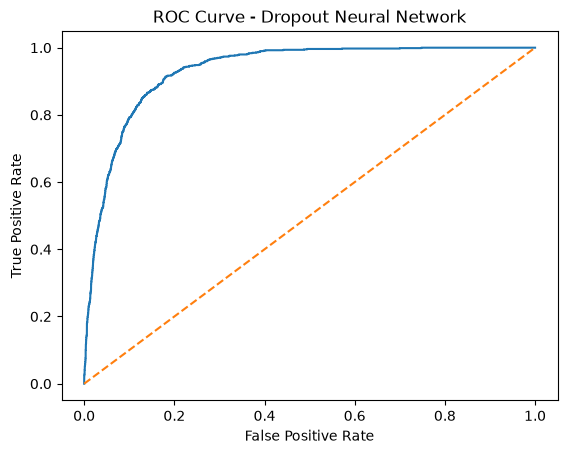

In [986]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

fpr, tpr, thresholds = roc_curve(
    dropout_targets,
    dropout_probabilities
)

plt.plot(fpr, tpr)
plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Dropout Neural Network")

plt.show()

In [988]:
import numpy as np
from sklearn.metrics import precision_score, recall_score, f1_score

thresholds_to_test = np.arange(0.1, 1.0, 0.1)

print("Threshold | Precision | Recall | F1-score")
print("-" * 45)

for threshold in thresholds_to_test:

    predictions = (
        np.array(dropout_probabilities) >= threshold
    ).astype(int)

    precision = precision_score(
        dropout_targets,
        predictions,
        zero_division=0
    )

    recall = recall_score(
        dropout_targets,
        predictions,
        zero_division=0
    )

    f1 = f1_score(
        dropout_targets,
        predictions,
        zero_division=0
    )

    print(
        f"{threshold:.1f}       | "
        f"{precision:.3f}     | "
        f"{recall:.3f}  | "
        f"{f1:.3f}"
    )

Threshold | Precision | Recall | F1-score
---------------------------------------------
0.1       | 0.271     | 0.980  | 0.424
0.2       | 0.318     | 0.962  | 0.478
0.3       | 0.348     | 0.946  | 0.509
0.4       | 0.376     | 0.926  | 0.535
0.5       | 0.405     | 0.902  | 0.559
0.6       | 0.441     | 0.869  | 0.585
0.7       | 0.494     | 0.809  | 0.613
0.8       | 0.554     | 0.705  | 0.620
0.9       | 0.683     | 0.427  | 0.526


In [990]:
import numpy as np
from sklearn.metrics import f1_score

thresholds = np.arange(0.01, 1.00, 0.01)

best_threshold = 0
best_f1 = 0

for threshold in thresholds:

    predictions = (
        np.array(dropout_probabilities) >= threshold
    ).astype(int)

    f1 = f1_score(
        dropout_targets,
        predictions,
        zero_division=0
    )

    if f1 > best_f1:
        best_f1 = f1
        best_threshold = threshold

print("Best validation threshold:", best_threshold)
print("Best validation F1-score:", best_f1)

Best validation threshold: 0.76
Best validation F1-score: 0.6269270298047277


In [992]:
dropout_model.eval()

test_probabilities = []
test_predictions = []
test_targets = []

with torch.no_grad():

    for X_batch, y_batch in test_loader:

        outputs = dropout_model(X_batch)

        probabilities = torch.sigmoid(
            outputs.squeeze(1)
        )

        predictions = (
            probabilities >= best_threshold
        ).float()

        test_probabilities.extend(
            probabilities.numpy()
        )

        test_predictions.extend(
            predictions.numpy()
        )

        test_targets.extend(
            y_batch.numpy()
        )

print("Final test predictions generated.")

print("Test samples:", len(test_targets))
print("Decision threshold:", best_threshold)

Final test predictions generated.
Test samples: 6782
Decision threshold: 0.76


In [994]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

test_accuracy = accuracy_score(
    test_targets,
    test_predictions
)

test_precision = precision_score(
    test_targets,
    test_predictions,
    zero_division=0
)

test_recall = recall_score(
    test_targets,
    test_predictions,
    zero_division=0
)

test_f1 = f1_score(
    test_targets,
    test_predictions,
    zero_division=0
)

test_roc_auc = roc_auc_score(
    test_targets,
    test_probabilities
)

print("FINAL TEST RESULTS")
print("-" * 30)

print(f"Accuracy : {test_accuracy:.4f}")
print(f"Precision: {test_precision:.4f}")
print(f"Recall   : {test_recall:.4f}")
print(f"F1-score : {test_f1:.4f}")
print(f"ROC-AUC  : {test_roc_auc:.4f}")

FINAL TEST RESULTS
------------------------------
Accuracy : 0.8843
Precision: 0.5033
Recall   : 0.7730
F1-score : 0.6096
ROC-AUC  : 0.9232


In [996]:
from sklearn.metrics import confusion_matrix

test_cm = confusion_matrix(
    test_targets,
    test_predictions
)

print("Final Test Confusion Matrix:")
print(test_cm)

Final Test Confusion Matrix:
[[5384  605]
 [ 180  613]]


In [998]:
import torch

torch.save(
    dropout_model.state_dict(),
    "bank_marketing_nn.pth"
)

print("Model saved successfully as bank_marketing_nn.pth")

Model saved successfully as bank_marketing_nn.pth


In [999]:
import joblib

joblib.dump(
    preprocessor,
    "bank_marketing_preprocessor.pkl"
)

print("Preprocessor saved successfully as bank_marketing_preprocessor.pkl")

Preprocessor saved successfully as bank_marketing_preprocessor.pkl
